# 🌿 Geo-Engine Classifier — Hyperparameter Tuning

This notebook performs **GridSearchCV** tuning across three classifiers:
- 🌲 **Random Forest**
- 🔷 **Support Vector Machine (SVM)**
- ⚡ **XGBoost**

Satellite imagery from **Sentinel-2 (SR Harmonized)** is sampled over the campus boundary, and spectral bands `B4`, `B8`, and `NDVI` are used as features to classify forest vs. non-forest pixels.

---

## 1. Imports & Setup

In [1]:
import os
import ee
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

load_dotenv()
ee.Initialize(project=os.getenv('EE_PROJECT_ID'))
print("✅ Earth Engine initialized.")

/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/api_core/_py

✅ Earth Engine initialized.


---
## 2. Define Study Area & Load Sentinel-2 Imagery

The campus boundary is defined as a GeoJSON polygon. We load cloud-filtered Sentinel-2 SR imagery from **Jan–Feb 2026** and compute a median composite.

In [2]:
campus_geojson = {
    "type": "Polygon",
    "coordinates": [
        [
            [80.01710357666015, 23.173962177472703],
            [80.03259601593017, 23.165361215115187],
            [80.03654422760009, 23.172502420044232],
            [80.026802444458,   23.181694681000845],
            [80.01542987823485, 23.176960548201308],
        ]
    ]
}
campus = ee.Geometry(campus_geojson)

def mask_s2_clouds(image):
    """Mask clouds and cirrus in Sentinel-2 images using the QA60 band."""
    qa = image.select('QA60')
    cloud  = 1 << 10
    cirrus = 1 << 11
    mask = qa.bitwiseAnd(cloud).eq(0).And(qa.bitwiseAnd(cirrus).eq(0))
    return image.updateMask(mask).divide(10000)

print("Loading Earth Engine data...")
train_dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate('2026-01-01', '2026-02-28')
      .filterBounds(campus)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 5))
      .map(mask_s2_clouds)
)

train_image = train_dataset.median().clip(campus)
print("✅ Sentinel-2 median composite created.")

Loading Earth Engine data...
✅ Sentinel-2 median composite created.


---
## 3. Compute NDVI & Prepare Feature Bands

NDVI (Normalized Difference Vegetation Index) is computed from the NIR (`B8`) and Red (`B4`) bands:

$$\text{NDVI} = \frac{B8 - B4}{B8 + B4}$$

In [3]:
ndvi = train_image.normalizedDifference(['B8', 'B4']).rename('NDVI')
train_image = train_image.addBands(ndvi)
bands = ['B4', 'B8', 'NDVI']
print(f"Feature bands: {bands}")

Feature bands: ['B4', 'B8', 'NDVI']


---
## 4. Sample Training Points from Earth Engine

Forest and non-forest point collections are merged and used to sample pixel values from the composite image.

In [4]:
forest_points     = ee.FeatureCollection('users/ashutoshsaxena703/forest_points_train')
non_forest_points = ee.FeatureCollection('users/ashutoshsaxena703/non_forest_points_train')
training_points   = forest_points.merge(non_forest_points)

print("Sampling feature regions...")
training = (
    train_image.select(bands)
               .sampleRegions(
                   collection=training_points,
                   properties=['label'],
                   scale=10
               )
               .filter(ee.Filter.notNull(bands + ['label']))
)

train_data_list = training.getInfo()['features']
print(f"✅ Extraction complete! {len(train_data_list)} points found.")

Sampling feature regions...


EEException: Collection.loadTable: Collection asset 'users/cosypix/forest_points' not found.

---
## 5. Build DataFrame for Sklearn

In [12]:
df = pd.DataFrame([feat['properties'] for feat in train_data_list])
X  = df[bands]
y  = df['label']

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts().rename({0: 'Non-Forest', 1: 'Forest'})}")
df.head()

Dataset shape: (500, 3)
Class distribution:
label
Forest        250
Non-Forest    250
Name: count, dtype: int64


,B4,B8,NDVI,label
0,0.06940,0.21325,0.508933,1
1,0.06940,0.21325,0.508933,1
2,0.05235,0.19595,0.578333,1
3,0.06300,0.17295,0.465989,1
4,0.05440,0.17430,0.524268,1


---
## 6. Define Models & Hyperparameter Grids

| Model | Key Hyperparameters |
|-------|--------------------|
| Random Forest | `n_estimators`, `min_samples_leaf`, `max_samples` |
| SVM | `kernel`, `C`, `gamma` |
| XGBoost | `n_estimators`, `learning_rate`, `max_depth` |

In [13]:
rf_model  = RandomForestClassifier(random_state=42, bootstrap=True)
svm_model = SVC(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

rf_grid = {
    'n_estimators':    [10, 50, 100, 150, 200, 300],
    'min_samples_leaf': [1, 3, 5],
    'max_samples':     [0.1, 0.3, 0.5, 0.7, 0.9, None]
}

svm_grid = [
    {'kernel': ['rbf'],    'gamma': [0.1, 0.5, 1.0], 'C': [1, 10, 100]},
    {'kernel': ['linear'], 'gamma': ['scale'],        'C': [1, 10, 100]}
]

xgb_grid = {
    'n_estimators':  [10, 20, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'max_depth':     [3, 5, 10]
}

pipelines = [
    ('Random Forest', rf_model,  rf_grid),
    ('SVM',          svm_model, svm_grid),
    ('XGBoost',      xgb_model, xgb_grid),
]

print("✅ Models and grids defined.")

✅ Models and grids defined.


---
## 7. Run GridSearchCV (5-Fold Cross-Validation)

In [14]:
all_results   = []
best_per_model = {}

for name, model, grid in pipelines:
    print(f"\n🔍 Running GridSearchCV for {name}...")
    search = GridSearchCV(
        model, grid,
        cv=5, scoring='accuracy',
        return_train_score=True, n_jobs=-1
    )
    search.fit(X, y)

    cv_res = pd.DataFrame(search.cv_results_)
    cv_res['Model'] = name
    cv_res['params_str'] = cv_res['params'].astype(str)

    param_cols    = [c for c in cv_res.columns if c.startswith('param_')]
    cols          = ['Model', 'params_str', 'mean_test_score', 'mean_train_score',
                     'std_test_score', 'rank_test_score'] + param_cols
    existing_cols = [c for c in cols if c in cv_res.columns]
    all_results.append(cv_res[existing_cols])

    best_per_model[name] = {
        'best_params': search.best_params_,
        'best_score':  search.best_score_
    }
    print(f"   ✅ Done. Best CV accuracy: {search.best_score_:.4f}")

final_df = pd.concat(all_results, ignore_index=True)
final_df = final_df.sort_values(by=['Model', 'rank_test_score'], ascending=[True, True])
final_df.to_csv('tuning_results.csv', index=False)
print("\n✅ Results saved to tuning_results.csv")


🔍 Running GridSearchCV for Random Forest...
   ✅ Done. Best CV accuracy: 0.9660

🔍 Running GridSearchCV for SVM...
   ✅ Done. Best CV accuracy: 0.9580

🔍 Running GridSearchCV for XGBoost...
   ✅ Done. Best CV accuracy: 0.9680

✅ Results saved to tuning_results.csv


---
## 8. Best Hyperparameters Summary

In [15]:
print("=" * 55)
print("       BEST HYPERPARAMETERS PER MODEL")
print("=" * 55)
for model_name, info in best_per_model.items():
    print(f"\n🏆 {model_name}")
    print(f"   Best CV Accuracy : {info['best_score']:.4f}")
    print(f"   Best Parameters  :")
    for k, v in info['best_params'].items():
        print(f"      {k:20s} = {v}")

print("\n" + "=" * 55)
overall_best = max(best_per_model.items(), key=lambda x: x[1]['best_score'])
print(f"\n🥇 Overall Best Model : {overall_best[0]}")
print(f"   Overall Best Score : {overall_best[1]['best_score']:.4f}")

       BEST HYPERPARAMETERS PER MODEL

🏆 Random Forest
   Best CV Accuracy : 0.9660
   Best Parameters  :
      max_samples          = 0.5
      min_samples_leaf     = 1
      n_estimators         = 10

🏆 SVM
   Best CV Accuracy : 0.9580
   Best Parameters  :
      C                    = 10
      gamma                = 1.0
      kernel               = rbf

🏆 XGBoost
   Best CV Accuracy : 0.9680
   Best Parameters  :
      learning_rate        = 0.01
      max_depth            = 5
      n_estimators         = 10


🥇 Overall Best Model : XGBoost
   Overall Best Score : 0.9680


---
## 9. Visualizations

### 9a. Random Forest — Effect of `n_estimators` on CV Score

Each line represents a different `min_samples_leaf` value, averaged over `max_samples`.

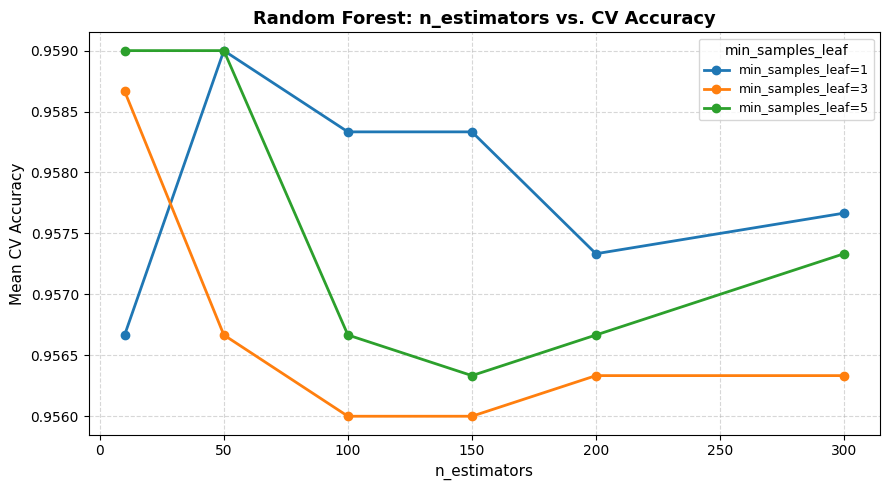

In [16]:
rf_df = final_df[final_df['Model'] == 'Random Forest'].copy()

if 'param_n_estimators' in rf_df.columns and 'param_min_samples_leaf' in rf_df.columns:
    rf_df['param_n_estimators']    = pd.to_numeric(rf_df['param_n_estimators'],    errors='coerce')
    rf_df['param_min_samples_leaf'] = pd.to_numeric(rf_df['param_min_samples_leaf'], errors='coerce')

    fig, ax = plt.subplots(figsize=(9, 5))
    colors = cm.tab10.colors

    for i, leaf in enumerate(sorted(rf_df['param_min_samples_leaf'].dropna().unique())):
        subset = rf_df[rf_df['param_min_samples_leaf'] == leaf]
        grouped = subset.groupby('param_n_estimators')['mean_test_score'].mean().reset_index()
        ax.plot(
            grouped['param_n_estimators'], grouped['mean_test_score'],
            marker='o', linewidth=2, markersize=6,
            label=f'min_samples_leaf={int(leaf)}', color=colors[i]
        )

    ax.set_title('Random Forest: n_estimators vs. CV Accuracy', fontsize=13, fontweight='bold')
    ax.set_xlabel('n_estimators', fontsize=11)
    ax.set_ylabel('Mean CV Accuracy', fontsize=11)
    ax.legend(title='min_samples_leaf', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('rf_n_estimators.png', dpi=150)
    plt.show()
else:
    print("RF param columns not found — skipping plot.")

### 9b. Random Forest — Effect of `max_samples` on CV Score

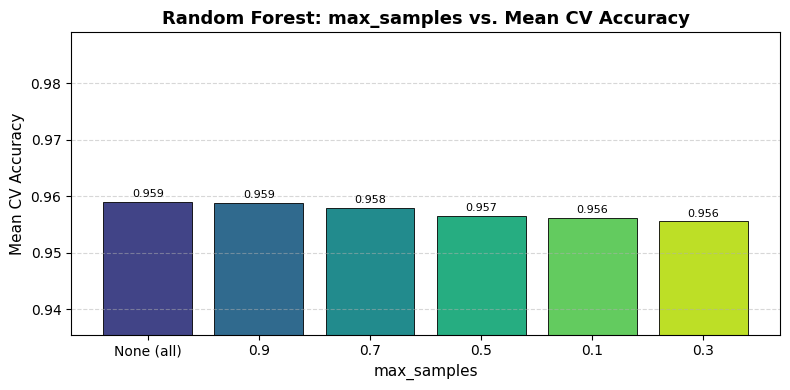

In [17]:
if 'param_max_samples' in rf_df.columns:
    rf_df2 = rf_df.copy()
    rf_df2['param_max_samples'] = rf_df2['param_max_samples'].fillna('None (all)')

    grouped_ms = (
        rf_df2.groupby('param_max_samples')['mean_test_score']
              .mean()
              .reset_index()
              .sort_values('mean_test_score', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(
        grouped_ms['param_max_samples'].astype(str),
        grouped_ms['mean_test_score'],
        color=cm.viridis(np.linspace(0.2, 0.9, len(grouped_ms))),
        edgecolor='black', linewidth=0.6
    )
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
    ax.set_title('Random Forest: max_samples vs. Mean CV Accuracy', fontsize=13, fontweight='bold')
    ax.set_xlabel('max_samples', fontsize=11)
    ax.set_ylabel('Mean CV Accuracy', fontsize=11)
    ax.set_ylim(grouped_ms['mean_test_score'].min() - 0.02, grouped_ms['mean_test_score'].max() + 0.03)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('rf_max_samples.png', dpi=150)
    plt.show()
else:
    print("RF max_samples column not found — skipping plot.")

### 9c. SVM — Effect of `C` and `kernel` on CV Score

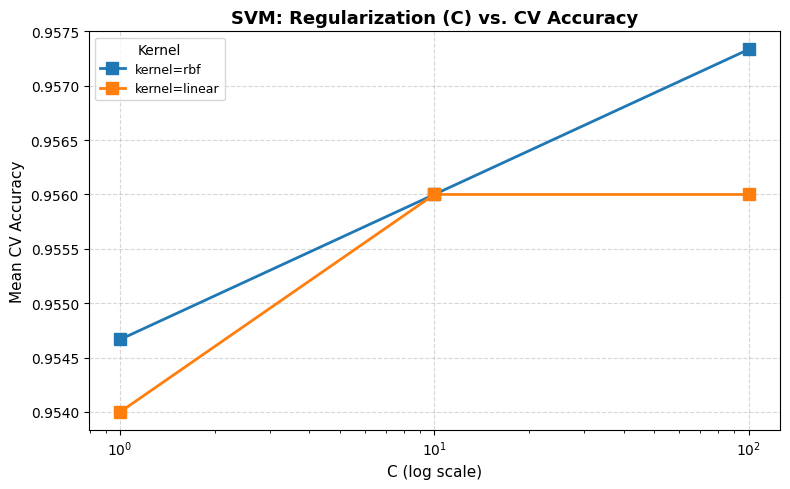

In [18]:
svm_df = final_df[final_df['Model'] == 'SVM'].copy()

if 'param_C' in svm_df.columns and 'param_kernel' in svm_df.columns:
    svm_df['param_C'] = pd.to_numeric(svm_df['param_C'], errors='coerce')

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, kernel in enumerate(svm_df['param_kernel'].dropna().unique()):
        subset  = svm_df[svm_df['param_kernel'] == kernel]
        grouped = subset.groupby('param_C')['mean_test_score'].mean().reset_index()
        ax.plot(
            grouped['param_C'], grouped['mean_test_score'],
            marker='s', linewidth=2, markersize=8,
            label=f'kernel={kernel}', color=cm.tab10.colors[i]
        )

    ax.set_xscale('log')
    ax.set_title('SVM: Regularization (C) vs. CV Accuracy', fontsize=13, fontweight='bold')
    ax.set_xlabel('C (log scale)', fontsize=11)
    ax.set_ylabel('Mean CV Accuracy', fontsize=11)
    ax.legend(title='Kernel', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('svm_C_kernel.png', dpi=150)
    plt.show()
else:
    print("SVM param columns not found — skipping plot.")

### 9d. XGBoost — Learning Rate vs. CV Score (by `max_depth`)

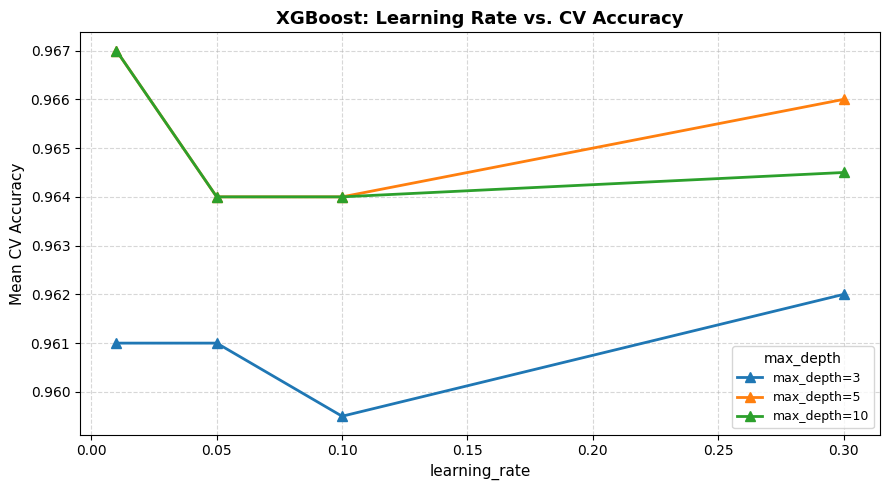

In [19]:
xgb_df = final_df[final_df['Model'] == 'XGBoost'].copy()

if 'param_learning_rate' in xgb_df.columns and 'param_max_depth' in xgb_df.columns:
    xgb_df['param_learning_rate'] = pd.to_numeric(xgb_df['param_learning_rate'], errors='coerce')
    xgb_df['param_max_depth']     = pd.to_numeric(xgb_df['param_max_depth'],     errors='coerce')

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, depth in enumerate(sorted(xgb_df['param_max_depth'].dropna().unique())):
        subset  = xgb_df[xgb_df['param_max_depth'] == depth]
        grouped = subset.groupby('param_learning_rate')['mean_test_score'].mean().reset_index()
        ax.plot(
            grouped['param_learning_rate'], grouped['mean_test_score'],
            marker='^', linewidth=2, markersize=7,
            label=f'max_depth={int(depth)}', color=cm.tab10.colors[i]
        )

    ax.set_title('XGBoost: Learning Rate vs. CV Accuracy', fontsize=13, fontweight='bold')
    ax.set_xlabel('learning_rate', fontsize=11)
    ax.set_ylabel('Mean CV Accuracy', fontsize=11)
    ax.legend(title='max_depth', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('xgb_lr_depth.png', dpi=150)
    plt.show()
else:
    print("XGB param columns not found — skipping plot.")

### 9e. XGBoost — `n_estimators` vs. CV Score

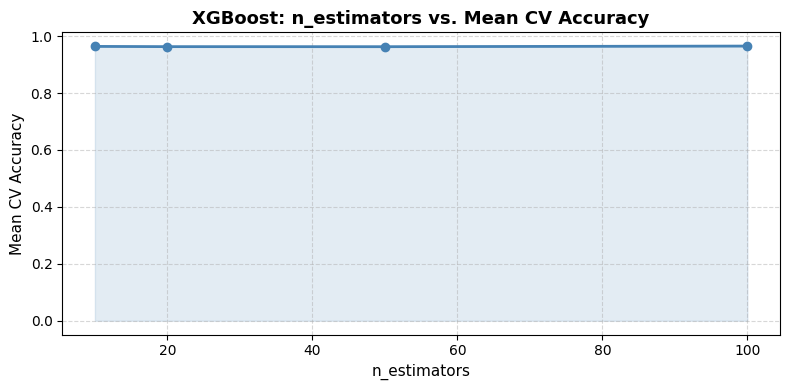

In [20]:
if 'param_n_estimators' in xgb_df.columns:
    xgb_df['param_n_estimators'] = pd.to_numeric(xgb_df['param_n_estimators'], errors='coerce')

    grouped_xgb = xgb_df.groupby('param_n_estimators')['mean_test_score'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.fill_between(
        grouped_xgb['param_n_estimators'], grouped_xgb['mean_test_score'],
        alpha=0.15, color='steelblue'
    )
    ax.plot(
        grouped_xgb['param_n_estimators'], grouped_xgb['mean_test_score'],
        marker='o', linewidth=2, color='steelblue'
    )
    ax.set_title('XGBoost: n_estimators vs. Mean CV Accuracy', fontsize=13, fontweight='bold')
    ax.set_xlabel('n_estimators', fontsize=11)
    ax.set_ylabel('Mean CV Accuracy', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('xgb_n_estimators.png', dpi=150)
    plt.show()
else:
    print("XGB n_estimators column not found — skipping plot.")

### 9f. Model Comparison — Best CV Score per Model

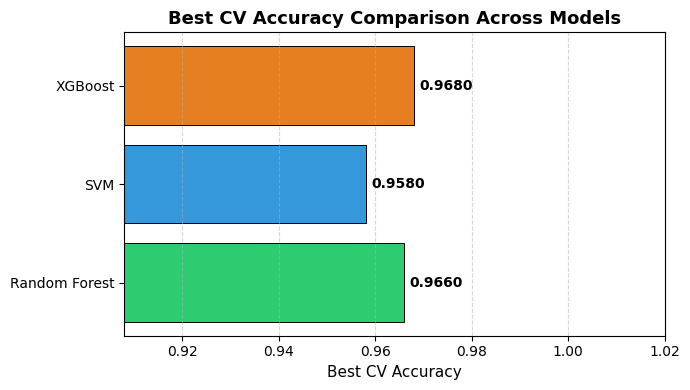

In [21]:
model_names  = list(best_per_model.keys())
best_scores  = [best_per_model[m]['best_score'] for m in model_names]
palette      = ['#2ecc71', '#3498db', '#e67e22']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(model_names, best_scores, color=palette, edgecolor='black', linewidth=0.7)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')
ax.set_xlim(min(best_scores) - 0.05, 1.02)
ax.set_title('Best CV Accuracy Comparison Across Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Best CV Accuracy', fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

---
## 10. Train vs. Test Score Analysis (Overfitting Check)

Large gaps between train and test scores indicate overfitting.

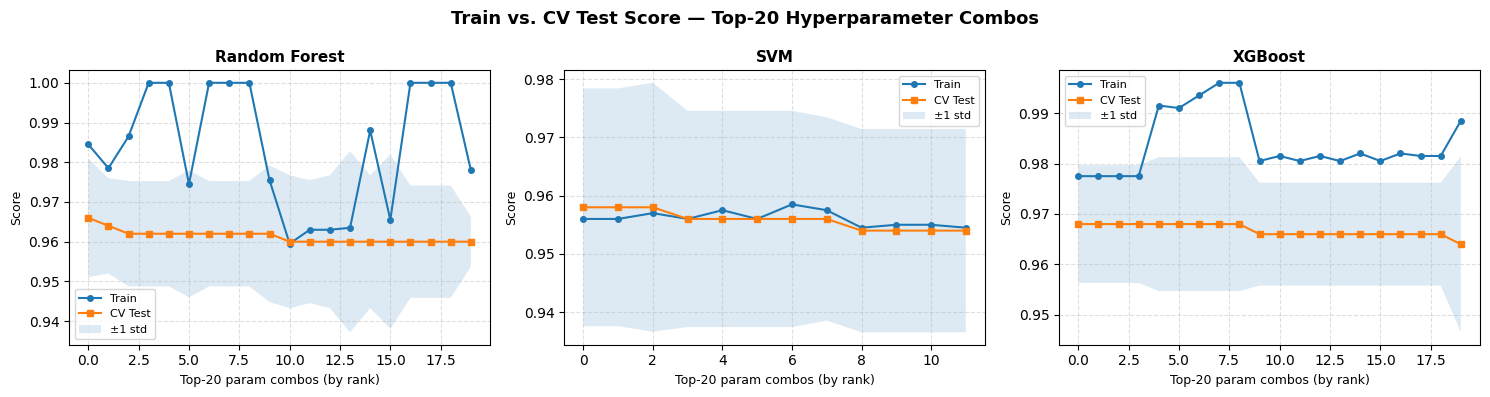

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, name in zip(axes, ['Random Forest', 'SVM', 'XGBoost']):
    sub = final_df[final_df['Model'] == name].sort_values('rank_test_score').head(20)
    x   = range(len(sub))
    ax.plot(x, sub['mean_train_score'].values, label='Train', marker='o', linewidth=1.5, markersize=4)
    ax.plot(x, sub['mean_test_score'].values,  label='CV Test', marker='s', linewidth=1.5, markersize=4)
    ax.fill_between(
        x,
        sub['mean_test_score'].values - sub['std_test_score'].values,
        sub['mean_test_score'].values + sub['std_test_score'].values,
        alpha=0.15, label='±1 std'
    )
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Top-20 param combos (by rank)', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Train vs. CV Test Score — Top-20 Hyperparameter Combos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_vs_test.png', dpi=150)
plt.show()